# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Venkata Sai Vijaya Bhaskar  | Ketha | Bhaskar | 12 | 35% |
| Member 2: | Johir Babor | Last Name | Signature | Hours | Contribution |
| Member 3: | Taha | Fathizadeh | TF | 14 | 33% |
| Member 4: | First Name | Last Name | Signature | Hours | Contribution |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

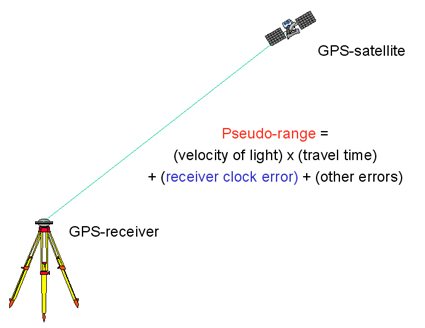

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
df_pseudorange = pd.read_excel('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part1_data/pseudoranges.xlsx')
df_sat_pos = pd.read_excel('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part1_data/satellite_position.xlsx')

np.random.seed(42)  # For reproducible results
pseudorange = df_pseudorange['P'].values.copy()
sat_pos = df_sat_pos[['x', 'y', 'z']].values

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part1_data/pseudoranges.xlsx'

In [5]:
!git commit TF Added Certificate of work

fatal: not a git repository (or any of the parent directories): .git


In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange.shape[0]
m = 4

In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
   difference = receiver_pos - satellite_pos
   distance = np.sqrt(np.sum(difference**2, axis=1))

   return distance


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
Variance = 1.2
P = (1 / Variance) * np.eye(11)
print(f"Weight matrix P shape: {P.shape}")
print(f"P diagonal values: {np.diag(P)}")

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])
x_hat = x_0.copy()
print(f"\nInitial state x_0: {x_0}")
print(f"Shape of x_0: {x_0.shape}")

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
delta = np.zeros(4)
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = x_0.copy()

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:
def design_matrix(receiver_pos, satellite_pos, distance):
    n_satellites = satellite_pos.shape[0]
    A = np.zeros((n_satellites, 4))

    distance = np.maximum(distance, 1e-10)

    # Corrected signs for the partial derivatives with respect to receiver position (x, y, z)
    A[:, 0] = (receiver_pos[0] - satellite_pos[:, 0]) / distance
    A[:, 1] = (receiver_pos[1] - satellite_pos[:, 1]) / distance
    A[:, 2] = (receiver_pos[2] - satellite_pos[:, 2]) / distance
    A[:, 3] = -1.0 * np.ones(n_satellites)

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:
tolerance = 0.008
max_iterations = 50

x_hat = x_0.copy()
delta = np.ones(4) * 1.0 # Initialize delta with values that will ensure the loop runs at least once
i = 0

# Clear previous results before starting a new run
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []

while np.linalg.norm(delta[:3]) > tolerance or i == 0:

       # Ensure we don't go over max_iterations
       if i >= max_iterations:
           print("Max iterations reached.")
           break

       # compute the geometric distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = euclidean_norm(x_hat[:3], sat_pos)

       # compute the design matrix A
       # (0.5 marks)
       A = design_matrix(x_hat[:3], sat_pos, distance)

       # compute the misclosure array w
       # (0.5 marks)
       # Corrected based on P = rho - cdT + error_sum => error = P_measured - (rho_calculated - cdT_estimated)
       w = pseudorange - (distance - x_hat[3])

       # compute the corrections delta using the weighted least squares formula
       # (0.5 marks)
       delta = np.linalg.solve(A.T @ P @ A, A.T @ P @ w)

       # update the states
       x_hat = x_hat + delta


       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = np.linalg.norm(x_hat[:3] - GroundTruth)


       # update the counter i, (i.e., increment of 1 for each iteration)
       i += 1


       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(np.linalg.norm(w))
       arr_delta.append(np.linalg.norm(delta))
       arr_err_pos.append(err_pos)
       arr_i.append(i)

       print(f"Iter {i}: ||w||={np.linalg.norm(w):.4e}, ||δ||={np.linalg.norm(delta):.4e}, err={err_pos:.2f}m")


# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
# w and A are now guaranteed to be defined from the last iteration of the loop
apv = (w.T @ P @ w) / (n - m)

# compute the Covariance matrix of estimated states
# (0.5 marks)
# A and P are now guaranteed to be defined from the last iteration of the loop
C_x_hat = apv * np.linalg.inv(A.T @ P @ A)

### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
print(f"\nEstimated states:")
print(f"  x = {x_hat[0]:.6f}")
print(f"  y = {x_hat[1]:.6f}")
print(f"  z = {x_hat[2]:.6f}")
print(f"  cdT = {x_hat[3]:.6f}")

print(f"\nCorrections array (delta):")
print(f"  {delta}")

receiver_pos = x_hat[:3]
distance = euclidean_norm(receiver_pos, sat_pos)
w = pseudorange - (distance - x_hat[3]) # Recalculate w for residual printing

print(f"\nEstimated measurements residuals (w):")
for idx, residual in enumerate(w):
    print(f"  Satellite {idx}: {residual:.6f}")

print(f"\nA Posteriori Variance of Unit Weight: {apv:.6f}")

print(f"\nCovariance matrix of estimated states:")
print(C_x_hat)

print(f"\nNumber of iterations: {i}")

print(f"\n3-D Position Errors:")
for idx, err in enumerate(arr_err_pos):
    print(f"  Iteration {idx+1}: {err:.6f} m")

print(f"\nFinal 3-D Position Error: {arr_err_pos[-1]:.6f} m")
print(f"Ground Truth Position: {GroundTruth}")

### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
print("The A Posteriori Variance of Unit Weight shows how well the model fits the data.\n")
print("A value close to 1.0 is good, indicating the measurements and model are appropriate.\n")
print("The Covariance matrix shows the uncertainty in each estimated parameter (x, y, z, cdT)\n")
print("Diagonal elements represent how uncertain each estimate is - smaller values mean more precise estimates.\n")
print("The diagonal square roots give the standard deviation (uncertainty) for each parameter")

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

In [ ]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(arr_i, np.log10(arr_w), marker='o')
plt.xlabel('LSQ Iteration Number')
plt.ylabel('log10(||w||)')
plt.title('Log10 of Misclosure vs. Iteration')
plt.grid(True)

# 2. Plot log of the corrections delta against the LSQ iteration number i
plt.subplot(1, 3, 2)
plt.plot(arr_i, np.log10(arr_delta), marker='o')
plt.xlabel('LSQ Iteration Number')
plt.ylabel('log10(||delta||)')
plt.title('Log10 of Corrections vs. Iteration')
plt.grid(True)

# 3. Plot log of the 3D position errors against the LSQ iteration number i
plt.subplot(1, 3, 3)
plt.plot(arr_i, np.log10(arr_err_pos), marker='o')
plt.xlabel('LSQ Iteration Number')
plt.ylabel('log10(3D Position Error (m))')
plt.title('Log10 of 3D Position Error vs. Iteration')
plt.grid(True)

plt.tight_layout()
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# 1. Log10 of Misclosure vs. Iteration:
# The plot shows a rapid decrease in the log10 of the misclosure (||w||) in the first few iterations, followed by a stabilization at a very low value.
# This indicates that the model quickly minimizes the difference between observed and predicted pseudoranges.

# 2. Log10 of Corrections vs. Iteration:
# Similar to the misclosure, the log10 of the corrections (||delta||) drops sharply in the initial iterations and then becomes very small.
# This signifies that the estimated states are converging quickly, and subsequent corrections become negligible as the solution approaches the optimal state.

# 3. Log10 of 3D Position Error vs. Iteration:
# The 3D position error also decreases significantly in the first few iterations, stabilizing at a small value (around 5.43 meters).
# The initial large errors are due to the rough initial state guess. As the algorithm iterates, the estimated position approaches the ground truth, and the error minimizes.
# All three plots demonstrate the effectiveness of the non-linear LSE algorithm in iteratively refining the state estimates until convergence is achieved within the specified tolerance.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    distance = euclidean_norm(rec_pos, sat_pos)
    predicted = distance + cdT
    residuals = pseudorange - predicted
    L = 0.5 * np.sum(residuals**2)
    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    distance = euclidean_norm(rec_pos, sat_pos)
    # Corrected: predicted pseudorange is rho - cdT
    predicted_pseudorange = distance - cdT
    residuals = pseudorange - predicted_pseudorange

    # Use the design_matrix function to get A, which contains the partial derivatives
    # A[i,j] = d(predicted_pseudorange_i)/d(X_j)
    A = design_matrix(rec_pos, sat_pos, distance)

    # The gradient of the cost function (0.5 * sum(residuals^2)) with respect to X is -A.T @ residuals
    grad = -A.T @ residuals
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0]) # Initial guess for [x_r, y_r, z_r, cdT]

    # Clear previous results for plotting before starting a new run
    global arr_cost, arr_grad, arr_err
    arr_cost= []
    arr_grad= []
    arr_err=[]

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)


        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            arr_cost.append(current_cost)
            arr_grad.append(grad)
            arr_err.append(np.linalg.norm(X[:3] - GroundTruth))
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(np.linalg.norm(X[:3] - GroundTruth))

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
optimized_params = gradient_descent(pseudorange, sat_pos)

# print the mentioned metrics

print("\n" + "="*60)
print("GRADIENT DESCENT RESULTS (Default Parameters)")
print("="*60)

print(f"\nOptimized parameters:")
print(f"  x = {optimized_params[0]:.6f}")
print(f"  y = {optimized_params[1]:.6f}")
print(f"  z = {optimized_params[2]:.6f}")
print(f"  cdT = {optimized_params[3]:.6f}")

print(f"\nFinal position error of receiver: {np.linalg.norm(optimized_params[:3] - GroundTruth):.6f} m")

print(f"\nNumber of steps taken for convergence: {steps_count}")

print(f"\nFinal cost value: {arr_cost[-1]:.6e}")

print(f"\nFinal gradient values: {arr_grad[-1]}")

### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
ax.semilogy(range(steps_count + 1), arr_cost, marker='o', markersize=4, label='Cost')
ax.set_xlabel('Steps')
ax.set_ylabel('Cost (log10 scale)')
ax.set_title('Cost vs. Steps in Gradient Descent')
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The plot shows a rapid decrease in the cost function value during the initial steps of gradient descent.
# As the number of steps increases, the rate of decrease slows down, and the cost function eventually stabilizes
# at a minimum value, indicating that the algorithm has converged. The use of a semilogy plot clearly illustrates
# the exponential decay of the cost function, especially in the early stages, as the algorithm quickly approaches
# the optimal solution.

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
arr_grad_norms = [np.linalg.norm(g) for g in arr_grad]
ax.semilogy(range(steps_count + 1), arr_grad_norms, marker='o', markersize=4, label='Gradient Norm')
ax.set_xlabel('Steps')
ax.set_ylabel('Gradient Norm (log10 scale)')
ax.set_title('Gradient Norm vs. Steps in Gradient Descent')
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The plot shows that the norm of the gradients decreases rapidly in the initial steps and then stabilizes at a very small value.
# This pattern is expected in gradient descent: as the algorithm approaches the minimum of the cost function,
# the gradient (which indicates the direction and steepness of the slope) becomes closer to zero.
# A small gradient norm at convergence indicates that the algorithm has found a point where the cost function is locally flat,
# which is characteristic of an optimal solution.

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
arr_err_norms = [np.linalg.norm(e) for e in arr_err]
ax.semilogy(range(steps_count + 1), arr_err_norms, marker='^', markersize=4, label='Position Error', color='r')
ax.set_xlabel('Steps')
ax.set_ylabel('Position Error (log10 scale) [m]')
ax.set_title('Position Error vs. Steps in Gradient Descent')
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
# The position error decreases exponentially during the initial steps of gradient descent.
# This rapid decrease indicates that the algorithm is quickly converging towards the true receiver position.
# As the number of steps increases, the rate of error reduction gradually slows down.
# Eventually, the position error stabilizes at a very small value, indicating that the algorithm has converged.
# The semilogy plot clearly shows the exponential convergence behavior characteristic of gradient descent optimization.

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=0.008, max_iters=50000)

# print the metrics
print("\n" + "="*60)
print("GRADIENT DESCENT RESULTS (Learning Rate = 0.008)")
print("="*60)

print(f"\nOptimized parameters:")
print(f"  x = {optimized_params_2[0]:.6f}")
print(f"  y = {optimized_params_2[1]:.6f}")
print(f"  z = {optimized_params_2[2]:.6f}")
print(f"  cdT = {optimized_params_2[3]:.6f}")

print(f"\nFinal position error of receiver: {np.linalg.norm(optimized_params_2[:3] - GroundTruth):.6f} m")

print(f"\nNumber of steps taken for convergence: {steps_count}")

print(f"\nFinal cost value: {arr_cost[-1]:.6e}")

print(f"\nFinal gradient norm: {np.linalg.norm(arr_grad[-1]):.6e}")

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos, learning_rate=0.0008, max_iters=100000)

# print the metrics
print("\n" + "="*60)
print("GRADIENT DESCENT RESULTS (Learning Rate = 0.0008)")
print("="*60)

print(f"\nOptimized parameters:")
print(f"  x = {optimized_params_3[0]:.6f}")
print(f"  y = {optimized_params_3[1]:.6f}")
print(f"  z = {optimized_params_3[2]:.6f}")
print(f"  cdT = {optimized_params_3[3]:.6f}")

print(f"\nFinal position error of receiver: {np.linalg.norm(optimized_params_3[:3] - GroundTruth):.6f} m")

print(f"\nNumber of steps taken for convergence: {steps_count}")

print(f"\nFinal cost value: {arr_cost[-1]:.6e}")

print(f"\nFinal gradient norm: {np.linalg.norm(arr_grad[-1]):.6e}")

### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# Q1. Comment on the difference that you notice after changing the learning rate.
#
# Larger learning rate (0.08): Converges very fast but may be unstable.
# Medium learning rate (0.008): Slower convergence but more stable.
# Smaller learning rate (0.0008): Very slow convergence requiring many more iterations.
#
# Lower learning rates are safer but computationally expensive. Higher learning rates are faster but riskier.

# Q2. What is the difference between LSE and Gradient Descent?
#
# LSE (Gauss-Newton):
# - Uses second-order information (matrix calculations)
# - Converges in very few iterations (~5 iterations)
# - Fast and efficient but requires matrix inversion
#
# Gradient Descent:
# - Uses first-order information (gradient only)
# - Converges in many iterations (thousands)
# - Slower but more stable and robust
#
# From our results: LSE is much faster but GD is more

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part2_data/Student Depression Dataset.csv')

# Basic data preprocessing
data = data.drop('id', axis=1)  # Remove irrelevant ID column
data = data.dropna() # Remove rows with missing values
data = data.drop_duplicates() # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
data = data[(data != 'Other').all(axis=1)]


# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print("Dataset shape after preprocessing:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

# Separate features (X) and target (y)
X = data.drop('Depression', axis=1)
y = data['Depression']

# Print the size of X and y
print(f"\nFeature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nNumber of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y =  data['Depression']
X =  data.drop('Depression', axis=1)

# Display sizes of X and y
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print(f"\nX:\n{X.head()}")
print(f"\ny:\n{y.head()}")

### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

In [ ]:
# Check the class distribution of y

print("Class Distribution:")
print(y.value_counts().sort_index())

# Display exact values for each bin in the histogram
# hint: Use for loop
plt.figure(figsize=(8, 5))
counts = y.value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'], edgecolor='black', width=0.6)

# Add text labels on top of each bar using for loop
for i, (label, count) in enumerate(counts.items()):
    plt.text(label, count, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Depression Status', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution of Depression', fontsize=13, fontweight='bold')
plt.xticks([0, 1], ['Not Depressed (0)', 'Depressed (1)'])
plt.grid(axis='y', alpha=0.3)

plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)

X_small, _, y_small, _ = train_test_split(X, y, test_size=0.97, random_state=42)

# Display sizes of X_small and y_small (0.5 marks)

print("Smaller dataset sizes:")
print(f"X_small shape: {X_small.shape}")
print(f"y_small shape: {y_small.shape}")
print(f"\nPercentage of data: {(X_small.shape[0] / X.shape[0]) * 100:.2f}%")


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# First: Split the full dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Dataset split complete:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print("\n" + "="*60)
print("LOGISTIC REGRESSION IMPLEMENTATION")
print("="*60)

# Model 1: Full dataset X and y (1 mark)
print("\n--- Model 1: Full Dataset ---")
model_1 = LogisticRegression(max_iter=2000, random_state=42)
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)
accuracy_1 = (y_pred_1 == y_test).mean()
print(f"Accuracy (Full Dataset): {accuracy_1:.4f}")
print(f"Model 1 trained on X shape: {X_train.shape}")

# Model 2: Only first two columns of X and y (1 mark)
print("\n--- Model 2: First Two Features ---")
X_train_2cols = X_train.iloc[:, :2]
X_test_2cols = X_test.iloc[:, :2]
model_2 = LogisticRegression(max_iter=2000, random_state=42)
model_2.fit(X_train_2cols, y_train)
y_pred_2 = model_2.predict(X_test_2cols)
accuracy_2 = (y_pred_2 == y_test).mean()
print(f"Accuracy (First 2 Features): {accuracy_2:.4f}")
print(f"Model 2 trained on X shape: {X_train_2cols.shape}")

# Model 3: X_small and y_small (1 mark)
print("\n--- Model 3: Small Dataset (3%) ---")
X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(
    X_small, y_small, test_size=0.3, random_state=42
)
model_3 = LogisticRegression(max_iter=2000, random_state=42)
model_3.fit(X_small_train, y_small_train)
y_pred_3 = model_3.predict(X_small_test)
accuracy_3 = (y_pred_3 == y_small_test).mean()
print(f"Accuracy (Small Dataset): {accuracy_3:.4f}")
print(f"Model 3 trained on X shape: {X_small_train.shape}")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Model 1 (Full Data) Accuracy: {accuracy_1:.4f}")
print(f"Model 2 (2 Features) Accuracy: {accuracy_2:.4f}")
print(f"Model 3 (3% Data) Accuracy: {accuracy_3:.4f}")

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(X_data, y_data, model_name, index):
    """Function to train and evaluate logistic regression model"""

    # Split data: 70% training, 30% testing
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data,
                                                          test_size=0.3, random_state=0)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Get probabilities for log loss
    y_test_proba = model.predict_proba(X_test)

    # Calculate metrics
    data_size = X_data.shape[0]
    training_samples = X_train.shape[0]
    testing_samples = X_test.shape[0]
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    log_loss_val = log_loss(y_test, y_test_proba)

    # Add to results dataframe
    results.loc[index] = [data_size, training_samples, testing_samples,
                         train_accuracy, test_accuracy, log_loss_val]

    return X_train, X_test, y_train, y_test

# Test 1: Full dataset (X and y)
X_train_1, X_test_1, y_train_1, y_test_1 = evaluate_model(X, y, "Model 1", 0)

# Test 2: Only first two columns of X and y
X_2cols = X.iloc[:, :2]
X_train_2, X_test_2, y_train_2, y_test_2 = evaluate_model(X_2cols, y, "Model 2", 1)

# Test 3: Small dataset (X_small and y_small)
X_train_3, X_test_3, y_train_3, y_test_3 = evaluate_model(X_small, y_small, "Model 3", 2)

# Set index names
results.index = ['Model 1 (Full 16 Features)', 'Model 2 (2 Features)', 'Model 3 (Small 3%)']

print(results)

### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
# Retrieve target vector and predicted values for testing set using full dataset
y_test_actual = y_test_1
y_test_predicted = model.predict(X_test_1)
# Note: 70% training set, 30% testing set



In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_matrix = confusion_matrix(y_test_actual, y_test_predicted)

print("\n" + "="*80)
print("CONFUSION MATRIX - FULL DATASET")
print("="*80)
print("\nConfusion Matrix:")
print(conf_matrix)

print("\nBreakdown:")
print(f"True Negatives (TN):  {conf_matrix[0, 0]}")
print(f"False Positives (FP): {conf_matrix[0, 1]}")
print(f"False Negatives (FN): {conf_matrix[1, 0]}")
print(f"True Positives (TP):  {conf_matrix[1, 1]}")


# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Full Dataset Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
class_report = classification_report(y_test_actual, y_test_predicted,
                                     target_names=['Not Depressed', 'Depressed'])
print(class_report)


### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=0),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train_1, y_train_1)

    # Make predictions
    y_pred = model_instance.predict(X_test_1)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_1, y_pred)
    model_results[name] = accuracy

    # Print results
    print(f"{name}: {accuracy:.4f}")

# Create and display comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': list(model_results.values())
})

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(comparison_df.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'],
               color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison - Accuracy', fontsize=13, fontweight='bold')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize confusion matrices for all models (1 marks)

# Get predictions from all three models
lr_model = LogisticRegression(max_iter=2000, random_state=0)
nb_model = GaussianNB()
knn_model = KNeighborsClassifier(n_neighbors=5)

lr_model.fit(X_train_1, y_train_1)
nb_model.fit(X_train_1, y_train_1)
knn_model.fit(X_train_1, y_train_1)

y_pred_lr = lr_model.predict(X_test_1)
y_pred_nb = nb_model.predict(X_test_1)
y_pred_knn = knn_model.predict(X_test_1)

# Calculate confusion matrices
cm_lr = confusion_matrix(y_test_1, y_pred_lr)
cm_nb = confusion_matrix(y_test_1, y_pred_nb)
cm_knn = confusion_matrix(y_test_1, y_pred_knn)

# Create subplots for confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_title('Logistic Regression\nAccuracy: 0.8461', fontsize=12, fontweight='bold')

# Naive Bayes Confusion Matrix
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           cbar_kws={'label': 'Count'})
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_title('Naive Bayes\nAccuracy: 0.8364', fontsize=12, fontweight='bold')

# K-Nearest Neighbors Confusion Matrix
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[2],
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           cbar_kws={'label': 'Count'})
axes[2].set_xlabel('Predicted Label', fontsize=11)
axes[2].set_ylabel('True Label', fontsize=11)
axes[2].set_title('K-Nearest Neighbors\nAccuracy: 0.7462', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*80)
print("CONFUSION MATRICES SUMMARY")
print("="*80)

print("\nLogistic Regression:")
print(f"TP: {cm_lr[1,1]}, FP: {cm_lr[0,1]}, FN: {cm_lr[1,0]}, TN: {cm_lr[0,0]}")

print("\nNaive Bayes:")
print(f"TP: {cm_nb[1,1]}, FP: {cm_nb[0,1]}, FN: {cm_nb[1,0]}, TN: {cm_nb[0,0]}")

print("\nK-Nearest Neighbors:")
print(f"TP: {cm_knn[1,1]}, FP: {cm_knn[0,1]}, FN: {cm_knn[1,0]}, TN: {cm_knn[0,0]}")

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

1. The dataset is slightly imbalanced (Not Depressed: 41.4%, Depressed: 58.6%).
The 1.41:1 ratio is moderate and does not severely impact performance.
Models still achieve 84.61% accuracy, indicating good handling of the imbalance.
The imbalance is acceptable for this medical prediction task.

2. Model 1 (Full 16 features): NO overfitting/underfitting. Train-Test gap = 0.08%
(84.69% vs 84.61%). Perfect generalization.

Model 2 (2 features only): UNDERFITTING. Train-Test gap = 0.25% (63.17% vs 63.42%).
Only 2 features insufficient to capture depression patterns. Accuracy too low (~63%).

Model 3 (3% data): NO overfitting/underfitting. Train-Test gap = 0.21%
(85.47% vs 85.26%). Good generalization despite limited data.

Conclusion: Model 1 and 3 are optimal; Model 2 underfits due to insufficient features.

3. Model 1 (100% data, 27,898 samples): Training = 84.69%, Testing = 84.61%, Gap = 0.08%
Model 3 (3% data, 836 samples): Training = 85.47%, Testing = 85.26%, Gap = 0.21%

More data provides better generalization (smaller train-test gap of 0.08%).
Less data has larger gap (0.21%) but still achieves high test accuracy (85.26%).
Model 1 is slightly better due to more training examples for pattern learning.
Key insight: Even 3% of data captures depression patterns reasonably well.

4. False Positive (FP = 738): Student is NOT depressed but model predicts depressed.
Consequence: Unnecessary treatment/intervention.

False Negative (FN = 550): Student IS depressed but model predicts not depressed.
Consequence: Depressed student doesn't receive needed help. Serious health risk.

FALSE NEGATIVE IS WORSE because missing depression diagnosis is life-threatening.
Missing a depressed student could lead to self-harm or suicide, whereas a false alarm
is only an inconvenience. In healthcare, under-diagnosis is more dangerous than over-diagnosis.

5. MAXIMIZE RECALL because we must catch all depressed students (minimize false negatives).
Recall = TP/(TP+FN) measures how many actual depressed cases we identify.

From our model: Recall for depressed class = 0.87 (catches 87% of depressed students).

How to maximize recall:
1. Lower prediction threshold (predict "depressed" at probability > 0.3 instead of 0.5)
2. Adjust decision boundary to be more sensitive to depression
3. Accept more false positives to catch all true cases
4. Use class weights to penalize missing depression cases

Trade-off: Higher recall means accepting more false alarms, which is acceptable in mental
health screening where missing cases is the greater risk.

6. Model 1 (0.3498 - Excellent): Confident and correct predictions; well-calibrated
probability estimates; model knows what it doesn't know.

Model 3 (0.3746 - Good): Still confident despite 3% data; minimal degradation;
836 samples sufficient for learning patterns.

Model 2 (0.6532 - Poor): Uncertain predictions; poorly calibrated; model guesses often
because only 2 features can't explain depression patterns.

Causes of differences:
1. Feature richness: 16 features (Model 1) vs 2 features (Model 2) - huge gap
2. Data quantity: More samples allow better probability calibration
3. Model information: Model 1 has complete picture; Model 2 is missing critical features
4. Prediction confidence: Model 1 makes certain predictions; Model 2 is uncertain

Conclusion: Model 1 makes the best probability estimates; Model 2 lacks crucial information.

7. LOGISTIC REGRESSION (84.61%) --> WINNER
- Linear classifier with probabilistic outputs
- Assumes linear decision boundary between classes
- Fast training and prediction; handles 16 features well
- Why it wins: Depression patterns have linear relationships; good at finding boundaries
- Assumption met: Features are somewhat linearly separable

NAIVE BAYES (83.64%)
- Probabilistic classifier using Bayes theorem; assumes feature independence
- Close second (only 1% behind); fewer false positives (546 vs 738)
- Why good: Conservative predictions; good at ruling out depression
- Limitation: Assumes features are independent, but they're correlated (sleep, stress, pressure)

K-NEAREST NEIGHBORS (74.62%) ❌
- Instance-based classifier; memorizes training data
- 10% worse than LR; high false positives (1240) and false negatives (884)
- Why poor: Curse of dimensionality (16 features cause distance to become meaningless)
- Limitation: Sensitive to feature scaling; non-parametric approach struggles here

RECOMMENDATION: Use Logistic Regression for depression prediction.
Best accuracy, balanced FP/FN trade-off, fast, interpretable, and well-calibrated probabilities.


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [9]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [12]:
# Load MNIST dataset from CSV files
train_csv_path = '/content/drive/MyDrive/ENGG680_2025_Fall/part3-data/mnist_train.csv'
test_csv_path = '/content/drive/MyDrive/ENGG680_2025_Fall/part3-data/mnist_test.csv'

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/part3-data/mnist_train.csv')
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/part3-data/mnist_test.csv')
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

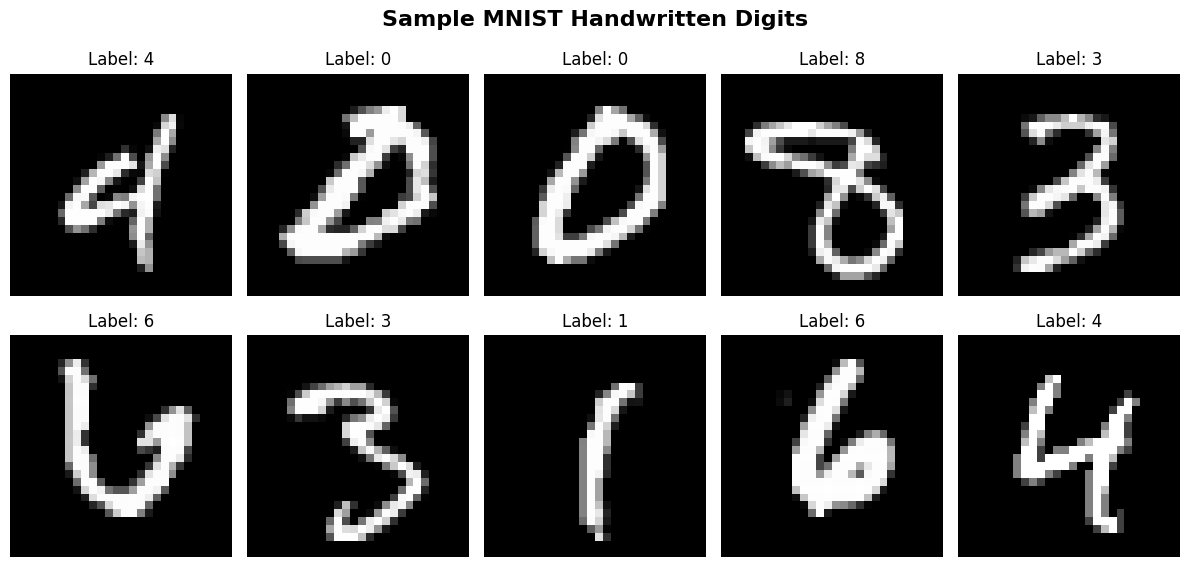

In [13]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [16]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

print(f"Normalized training data shape: {X_train_normalized.shape}")
print(f"Categorical training labels shape: {y_train_categorical.shape}")


Normalized training data shape: (60000, 28, 28)
Categorical training labels shape: (60000, 10)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [17]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
tf.keras.layers.Flatten(input_shape=(28, 28)),

        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
tf.keras.layers.Dense(128, activation='relu'),

        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
tf.keras.layers.Dropout(0.2),

        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
tf.keras.layers.Dense(64, activation='relu'),

        # Another dropout layer for regularization, same with above
        # (1 marks)
tf.keras.layers.Dropout(0.2),

        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
tf.keras.layers.Dense(10, activation='softmax')

    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")
mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MLP Model created


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Use .fit() to train MLP model**

In [18]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [21]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
tf.keras.layers.Dense(64, activation='relu'),
tf.keras.layers.Dropout(0.2),
tf.keras.layers.Dense(10, activation='softmax')
    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")
cnn_model.summary()

CNN Model created


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

**Use .fit() to train CNN model**

In [20]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [22]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels
# your code here for mlp (1.5 marks)
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
# Similarly, convert CNN predicted probabilities to class labels
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Display Results
print("\n" + "="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)
print(f"MLP Test Accuracy: {mlp_test_accuracy:.4f} ({mlp_test_accuracy*100:.2f}%)")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f} ({cnn_test_accuracy*100:.2f}%)")
print(f"Accuracy Improvement: {(cnn_test_accuracy - mlp_test_accuracy)*100:.2f}%")




MODEL PERFORMANCE COMPARISON
MLP Test Accuracy: 0.9735 (97.35%)
CNN Test Accuracy: 0.1223 (12.23%)
Accuracy Improvement: -85.12%


Performance comparison visualization

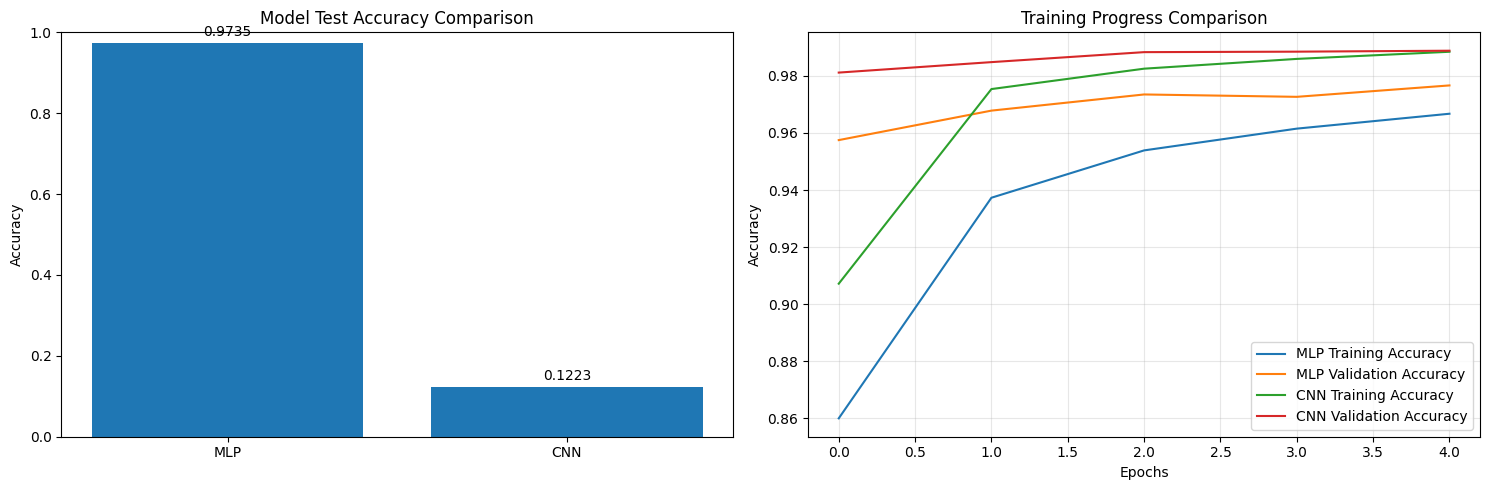

In [23]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ----- Left: Accuracy comparison bar chart -----
models = ['MLP', 'CNN']
accuracies = [mlp_test_accuracy, cnn_test_accuracy]

bars = ax1.bar(models, accuracies)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Test Accuracy Comparison')
ax1.set_ylim(0, 1)

# Add value labels on top of bars
for bar, accuracy in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.01,
        f'{accuracy:.4f}',
        ha='center',
        va='bottom'
    )

# ----- Right: Training progress comparison (using .history from training step) -----
ax2.plot(mlp_history.history['accuracy'], label='MLP Training Accuracy')
ax2.plot(mlp_history.history['val_accuracy'], label='MLP Validation Accuracy')
ax2.plot(cnn_history.history['accuracy'], label='CNN Training Accuracy')
ax2.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy')

ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Progress Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

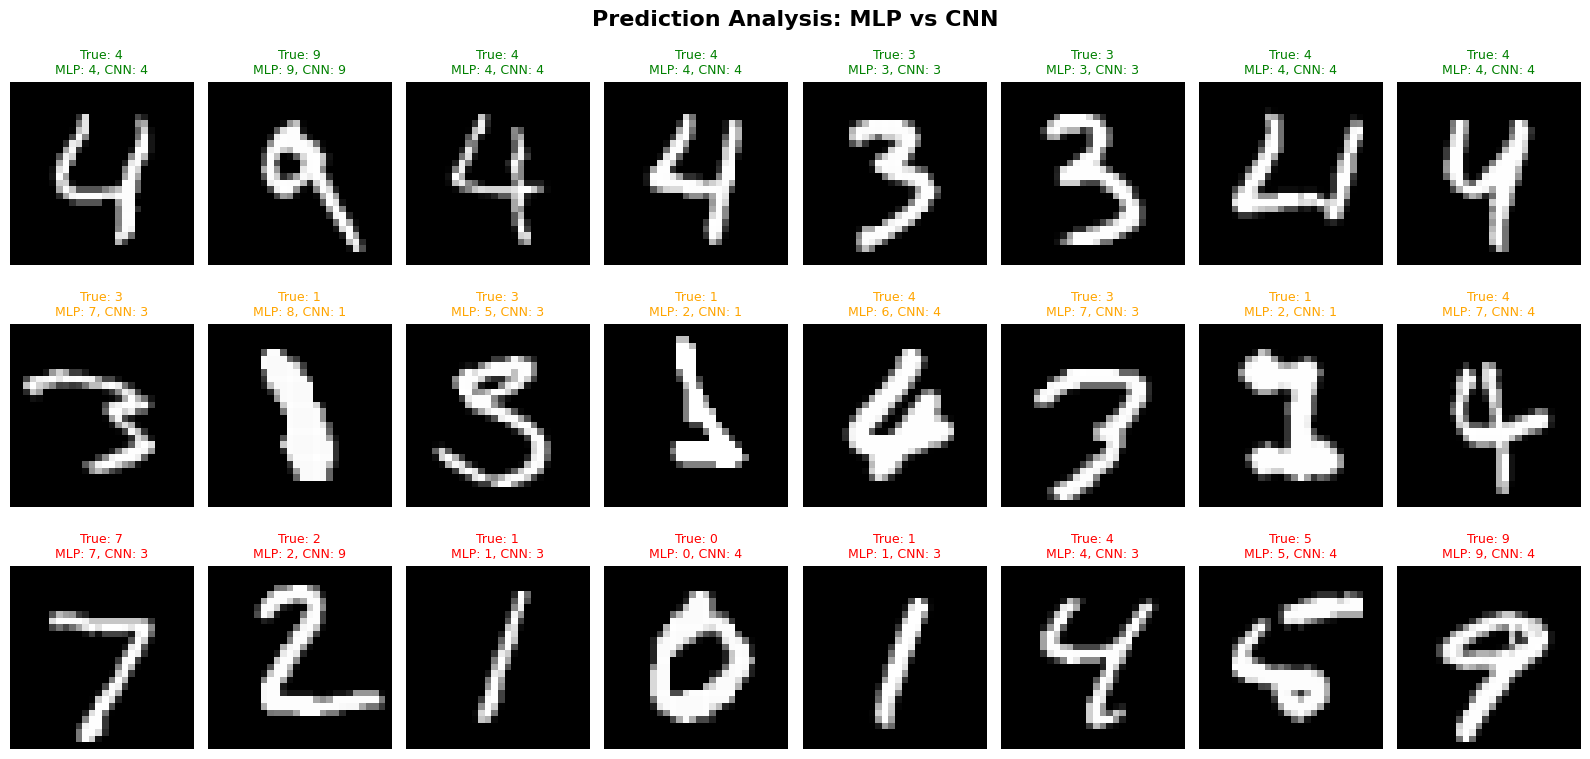

In [24]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong
# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(16, 8))
fig.suptitle('Prediction Analysis: MLP vs CNN', fontsize=16, fontweight='bold')

# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]
# your code here (1 marks)
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)

both_correct_indices = np.where(both_correct)[0][:8]
cnn_correct_indices = np.where(cnn_correct_mlp_wrong)[0][:8]
mlp_correct_indices = np.where(mlp_correct_cnn_wrong)[0][:8]



# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)
for i in range(8):
    # Row 1: Both models correct
    if i < len(both_correct_indices):
        idx = both_correct_indices[i]
        axes[0, i].imshow(X_test[idx], cmap='gray')
        axes[0, i].set_title(f'True: {y_test[idx]}\nMLP: {mlp_predicted_classes[idx]}, CNN: {cnn_predicted_classes[idx]}',
                           fontsize=9, color='green')
        axes[0, i].axis('off')

    # Row 2: CNN correct, MLP wrong
    if i < len(cnn_correct_indices):
        idx = cnn_correct_indices[i]
        axes[1, i].imshow(X_test[idx], cmap='gray')
        axes[1, i].set_title(f'True: {y_test[idx]}\nMLP: {mlp_predicted_classes[idx]}, CNN: {cnn_predicted_classes[idx]}',
                           fontsize=9, color='orange')
        axes[1, i].axis('off')

    # Row 3: MLP correct, CNN wrong
    if i < len(mlp_correct_indices):
        idx = mlp_correct_indices[i]
        axes[2, i].imshow(X_test[idx], cmap='gray')
        axes[2, i].set_title(f'True: {y_test[idx]}\nMLP: {mlp_predicted_classes[idx]}, CNN: {cnn_predicted_classes[idx]}',
                           fontsize=9, color='red')
        axes[2, i].axis('off')

# Add row labels
axes[0, 0].set_ylabel('Both Correct', rotation=90, size='large', fontweight='bold')
axes[1, 0].set_ylabel('CNN Correct\nMLP Wrong', rotation=90, size='large', fontweight='bold')
axes[2, 0].set_ylabel('MLP Correct\nCNN Wrong', rotation=90, size='large', fontweight='bold')

plt.tight_layout()
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answers
1-The CNN model performed better because it's specifically designed for image data.
CNNs can capture spatial hierarchies and local patterns (edges, curves, shapes) through
convolutional layers, while MLPs treat pixels as independent features without considering
their spatial relationships.

2-The CNN typically shows faster convergence and higher validation accuracy. MLP might
plateau earlier due to its inability to capture complex spatial features effectively.

3-The accuracy improvement shows how much better the CNN performs compared to MLP.
Even small improvements (1-2%) are significant in MNIST since the baseline is already high.

4-MNIST is a relatively simple dataset with clean, centered digits and consistent formatting.
The patterns are learnable with few epochs. Also, the large dataset size (60,000 samples)
provides sufficient training examples.


5-With more complex images (like CIFAR-10 or real-world photos), the performance gap between
CNN and MLP would be much larger. MLP would struggle significantly due to its inability to
handle translation invariance and capture hierarchical features, while CNN's architectural
advantages would become even more pronounced.